Dataset shape: (1122, 6, 15)
Crime labels distribution: [367 365 390]
Recovery labels distribution: [382 375 365]
Training TCN model...
Epoch 10/100, Train Loss: 1.3675, Val Loss: 1.4431
Epoch 20/100, Train Loss: 0.8458, Val Loss: 0.9310
Epoch 30/100, Train Loss: 0.6866, Val Loss: 0.7786
Epoch 40/100, Train Loss: 0.6470, Val Loss: 0.7755
Epoch 50/100, Train Loss: 0.5385, Val Loss: 0.6677
Epoch 60/100, Train Loss: 0.4510, Val Loss: 0.7166
Epoch 70/100, Train Loss: 0.4213, Val Loss: 0.6754
Epoch 80/100, Train Loss: 0.3994, Val Loss: 0.6671
Epoch 90/100, Train Loss: 0.3885, Val Loss: 0.6623
Epoch 100/100, Train Loss: 0.4025, Val Loss: 0.6678


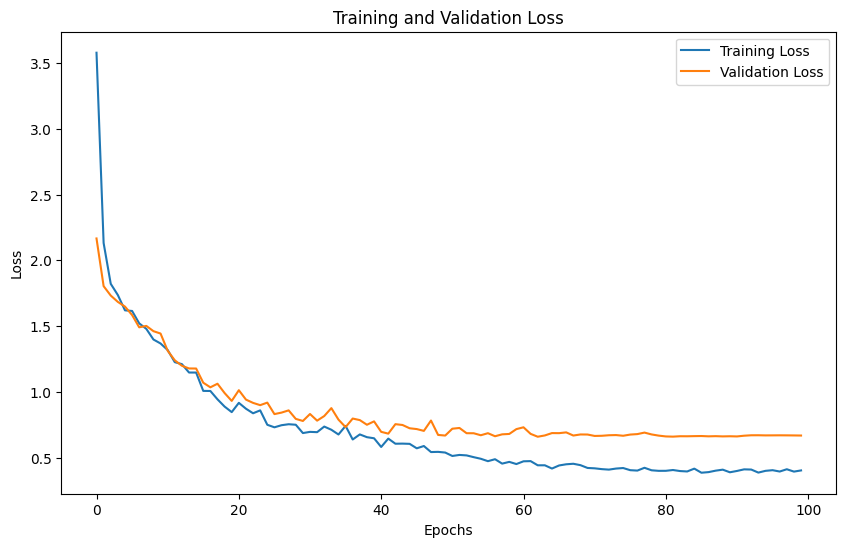


Evaluating model on test set...
Crime Level Accuracy: 0.9422
Recovery Level Accuracy: 0.8756


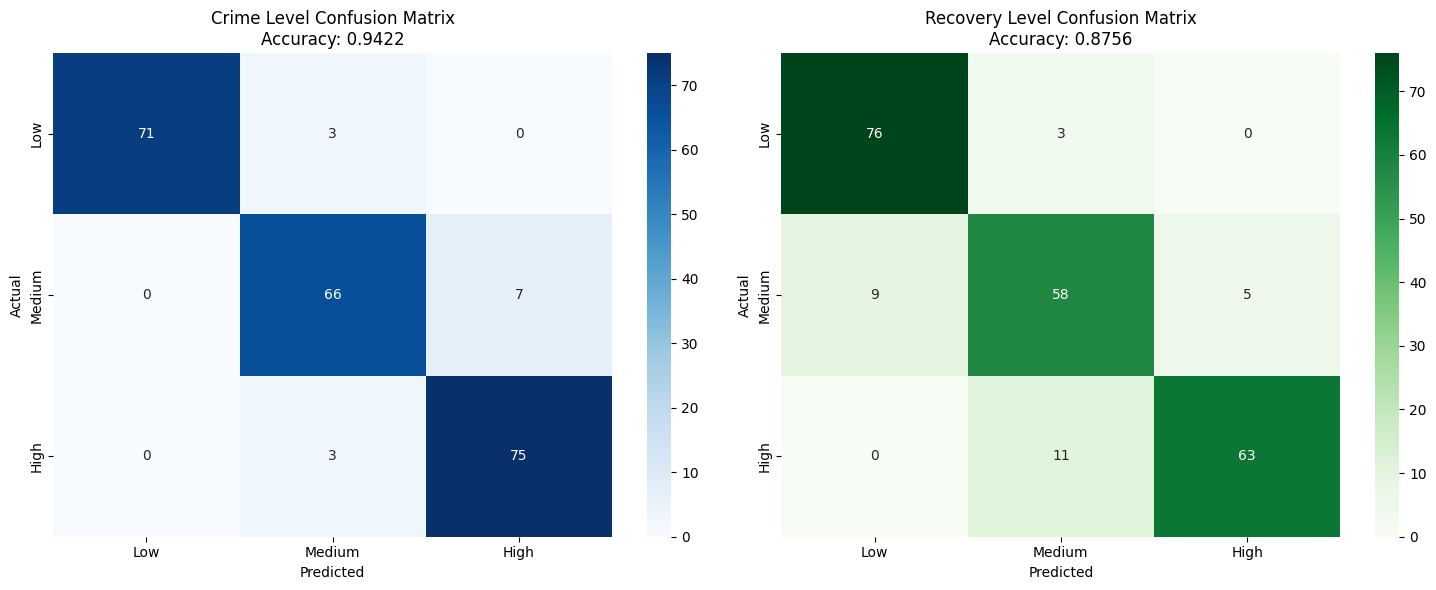


CRIME LEVEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       1.00      0.96      0.98        74
      Medium       0.92      0.90      0.91        73
        High       0.91      0.96      0.94        78

    accuracy                           0.94       225
   macro avg       0.94      0.94      0.94       225
weighted avg       0.94      0.94      0.94       225


RECOVERY LEVEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.89      0.96      0.93        79
      Medium       0.81      0.81      0.81        72
        High       0.93      0.85      0.89        74

    accuracy                           0.88       225
   macro avg       0.88      0.87      0.87       225
weighted avg       0.88      0.88      0.88       225


Calculating feature importance...


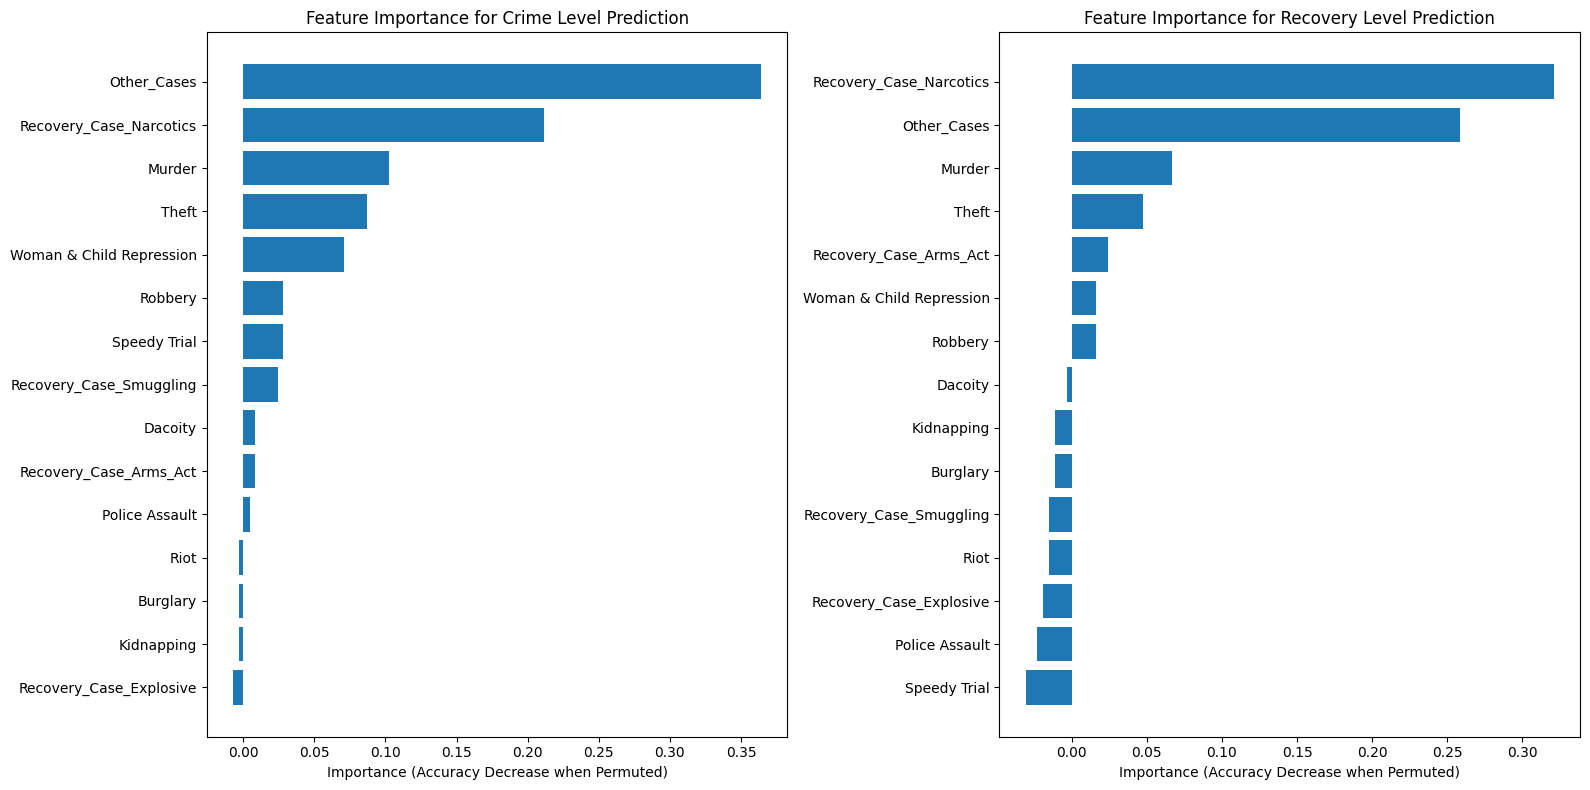


Top 5 Features for Crime Level Prediction:
  Woman & Child Repression: 0.0711
  Theft: 0.0868
  Murder: 0.1024
  Recovery_Case_Narcotics: 0.2118
  Other_Cases: 0.3641

Top 5 Features for Recovery Level Prediction:
  Recovery_Case_Arms_Act: 0.0240
  Theft: 0.0474
  Murder: 0.0670
  Other_Cases: 0.2584
  Recovery_Case_Narcotics: 0.3209

Model saved as 'tcn_crime_model.pth'


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load and preprocess data
df = pd.read_csv('/content/FINAL_MONTHLY_CRIME_DATA.csv')

# Feature selection
crime_features = ['Dacoity', 'Robbery', 'Murder', 'Speedy Trial', 'Riot',
                'Woman & Child Repression', 'Kidnapping', 'Police Assault',
                'Burglary', 'Theft', 'Other_Cases', 'Recovery_Case_Arms_Act',
                'Recovery_Case_Explosive', 'Recovery_Case_Narcotics', 'Recovery_Case_Smuggling']

target_columns = ['Crime_Level', 'Recovery_Level']

# Filter relevant columns
features_df = df[['Unit Name', 'Year', 'Month'] + crime_features + target_columns].copy()

# Encode categorical targets
level_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
features_df['Crime_Level_encoded'] = features_df['Crime_Level'].map(level_mapping)
features_df['Recovery_Level_encoded'] = features_df['Recovery_Level'].map(level_mapping)

# Create sequential data with time series for each unit
def create_sequences(data, unit_name, sequence_length=6):
    unit_data = data[data['Unit Name'] == unit_name].sort_values(['Year', 'Month'])
    sequences = []
    crime_labels = []
    recovery_labels = []

    for i in range(len(unit_data) - sequence_length):
        seq = unit_data.iloc[i:i+sequence_length][crime_features].values
        crime_label = unit_data.iloc[i+sequence_length]['Crime_Level_encoded']
        recovery_label = unit_data.iloc[i+sequence_length]['Recovery_Level_encoded']

        sequences.append(seq)
        crime_labels.append(crime_label)
        recovery_labels.append(recovery_label)

    return sequences, crime_labels, recovery_labels

# Create dataset
all_sequences = []
all_crime_labels = []
all_recovery_labels = []

unique_units = features_df['Unit Name'].unique()
sequence_length = 6

for unit in unique_units:
    unit_sequences, crime_labs, recovery_labs = create_sequences(features_df, unit, sequence_length)
    all_sequences.extend(unit_sequences)
    all_crime_labels.extend(crime_labs)
    all_recovery_labels.extend(recovery_labs)

# Convert to numpy arrays
X = np.array(all_sequences)
y_crime = np.array(all_crime_labels)
y_recovery = np.array(all_recovery_labels)

print(f"Dataset shape: {X.shape}")
print(f"Crime labels distribution: {np.bincount(y_crime)}")
print(f"Recovery labels distribution: {np.bincount(y_recovery)}")

# TCN Model
class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = nn.ConstantPad1d((0, -padding), 0)  # Causal padding
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = nn.ConstantPad1d((0, -padding), 0)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TCN(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=2, dropout=0.2):
        super(TCN, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size, dropout=dropout)]

        self.network = nn.Sequential(*layers)
        self.crime_classifier = nn.Linear(num_channels[-1], 3)  # 3 classes for crime level
        self.recovery_classifier = nn.Linear(num_channels[-1], 3)  # 3 classes for recovery level

    def forward(self, x):
        # x shape: (batch, sequence_length, num_features)
        x = x.transpose(1, 2)  # Convert to (batch, num_features, sequence_length)
        out = self.network(x)
        out = out[:, :, -1]  # Take the last output for classification

        crime_out = self.crime_classifier(out)
        recovery_out = self.recovery_classifier(out)

        return crime_out, recovery_out

# Custom Dataset
class CrimeDataset(Dataset):
    def __init__(self, sequences, crime_labels, recovery_labels):
        self.sequences = torch.FloatTensor(sequences)
        self.crime_labels = torch.LongTensor(crime_labels)
        self.recovery_labels = torch.LongTensor(recovery_labels)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.crime_labels[idx], self.recovery_labels[idx]

# Split data
X_train, X_test, y_crime_train, y_crime_test, y_recovery_train, y_recovery_test = train_test_split(
    X, y_crime, y_recovery, test_size=0.2, random_state=42, stratify=y_crime
)

X_train, X_val, y_crime_train, y_crime_val, y_recovery_train, y_recovery_val = train_test_split(
    X_train, y_crime_train, y_recovery_train, test_size=0.2, random_state=42, stratify=y_crime_train
)

# Create datasets and dataloaders
train_dataset = CrimeDataset(X_train, y_crime_train, y_recovery_train)
val_dataset = CrimeDataset(X_val, y_crime_val, y_recovery_val)
test_dataset = CrimeDataset(X_test, y_crime_test, y_recovery_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model parameters
num_features = len(crime_features)
num_channels = [64, 32, 16]  # TCN channels
model = TCN(num_features, num_channels, kernel_size=3, dropout=0.3)

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# Training function
def train_model(model, train_loader, val_loader, epochs=50):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_idx, (data, crime_target, recovery_target) in enumerate(train_loader):
            optimizer.zero_grad()
            crime_pred, recovery_pred = model(data)

            crime_loss = criterion(crime_pred, crime_target)
            recovery_loss = criterion(recovery_pred, recovery_target)
            loss = crime_loss + recovery_loss

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, crime_target, recovery_target in val_loader:
                crime_pred, recovery_pred = model(data)

                crime_loss = criterion(crime_pred, crime_target)
                recovery_loss = criterion(recovery_pred, recovery_target)
                loss = crime_loss + recovery_loss

                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        scheduler.step(avg_val_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

    return train_losses, val_losses

# Train the model
print("Training TCN model...")
train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=100)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    crime_preds = []
    crime_targets = []
    recovery_preds = []
    recovery_targets = []

    crime_probs = []
    recovery_probs = []

    with torch.no_grad():
        for data, crime_target, recovery_target in test_loader:
            crime_pred, recovery_pred = model(data)

            crime_preds.extend(torch.argmax(crime_pred, dim=1).cpu().numpy())
            crime_targets.extend(crime_target.cpu().numpy())
            recovery_preds.extend(torch.argmax(recovery_pred, dim=1).cpu().numpy())
            recovery_targets.extend(recovery_target.cpu().numpy())

            crime_probs.extend(torch.softmax(crime_pred, dim=1).cpu().numpy())
            recovery_probs.extend(torch.softmax(recovery_pred, dim=1).cpu().numpy())

    return (crime_preds, crime_targets, recovery_preds, recovery_targets,
            crime_probs, recovery_probs)

# Evaluate the model
print("\nEvaluating model on test set...")
crime_preds, crime_targets, recovery_preds, recovery_targets, crime_probs, recovery_probs = evaluate_model(model, test_loader)

# Calculate accuracies
crime_accuracy = accuracy_score(crime_targets, crime_preds)
recovery_accuracy = accuracy_score(recovery_targets, recovery_preds)

print(f"Crime Level Accuracy: {crime_accuracy:.4f}")
print(f"Recovery Level Accuracy: {recovery_accuracy:.4f}")

# Confusion matrices
crime_cm = confusion_matrix(crime_targets, crime_preds)
recovery_cm = confusion_matrix(recovery_targets, recovery_preds)

# Plot confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Crime Level Confusion Matrix
sns.heatmap(crime_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'], ax=ax1)
ax1.set_title(f'Crime Level Confusion Matrix\nAccuracy: {crime_accuracy:.4f}')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Recovery Level Confusion Matrix
sns.heatmap(recovery_cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'], ax=ax2)
ax2.set_title(f'Recovery Level Confusion Matrix\nAccuracy: {recovery_accuracy:.4f}')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Detailed classification reports
print("\n" + "="*50)
print("CRIME LEVEL CLASSIFICATION REPORT")
print("="*50)
print(classification_report(crime_targets, crime_preds, target_names=['Low', 'Medium', 'High']))

print("\n" + "="*50)
print("RECOVERY LEVEL CLASSIFICATION REPORT")
print("="*50)
print(classification_report(recovery_targets, recovery_preds, target_names=['Low', 'Medium', 'High']))

# Feature importance analysis (using permutation importance)
def permutation_importance(model, test_loader, feature_names):
    model.eval()
    baseline_crime_preds = []
    baseline_recovery_preds = []
    crime_targets = []
    recovery_targets = []

    with torch.no_grad():
        for data, crime_target, recovery_target in test_loader:
            crime_pred, recovery_pred = model(data)
            baseline_crime_preds.extend(torch.argmax(crime_pred, dim=1).cpu().numpy())
            baseline_recovery_preds.extend(torch.argmax(recovery_pred, dim=1).cpu().numpy())
            crime_targets.extend(crime_target.cpu().numpy())
            recovery_targets.extend(recovery_target.cpu().numpy())

    baseline_crime_acc = accuracy_score(crime_targets, baseline_crime_preds)
    baseline_recovery_acc = accuracy_score(recovery_targets, baseline_recovery_preds)

    crime_importance = []
    recovery_importance = []

    for feature_idx in range(len(feature_names)):
        # Permute feature
        permuted_crime_acc = 0
        permuted_recovery_acc = 0
        num_batches = 0

        with torch.no_grad():
            for data, crime_target, recovery_target in test_loader:
                # Permute the specific feature across the sequence
                permuted_data = data.clone()
                permuted_data[:, :, feature_idx] = permuted_data[torch.randperm(permuted_data.size(0)), :, feature_idx]

                crime_pred, recovery_pred = model(permuted_data)
                crime_preds = torch.argmax(crime_pred, dim=1).cpu().numpy()
                recovery_preds = torch.argmax(recovery_pred, dim=1).cpu().numpy()

                permuted_crime_acc += accuracy_score(crime_target.cpu().numpy(), crime_preds)
                permuted_recovery_acc += accuracy_score(recovery_target.cpu().numpy(), recovery_preds)
                num_batches += 1

        avg_permuted_crime_acc = permuted_crime_acc / num_batches
        avg_permuted_recovery_acc = permuted_recovery_acc / num_batches

        crime_importance.append(baseline_crime_acc - avg_permuted_crime_acc)
        recovery_importance.append(baseline_recovery_acc - avg_permuted_recovery_acc)

    return crime_importance, recovery_importance

print("\nCalculating feature importance...")
crime_importance, recovery_importance = permutation_importance(model, test_loader, crime_features)

# Plot feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Crime Level Feature Importance
crime_imp_df = pd.DataFrame({
    'Feature': crime_features,
    'Importance': crime_importance
}).sort_values('Importance', ascending=True)

ax1.barh(crime_imp_df['Feature'], crime_imp_df['Importance'])
ax1.set_title('Feature Importance for Crime Level Prediction')
ax1.set_xlabel('Importance (Accuracy Decrease when Permuted)')

# Recovery Level Feature Importance
recovery_imp_df = pd.DataFrame({
    'Feature': crime_features,
    'Importance': recovery_importance
}).sort_values('Importance', ascending=True)

ax2.barh(recovery_imp_df['Feature'], recovery_imp_df['Importance'])
ax2.set_title('Feature Importance for Recovery Level Prediction')
ax2.set_xlabel('Importance (Accuracy Decrease when Permuted)')

plt.tight_layout()
plt.show()

# Print top features
print("\nTop 5 Features for Crime Level Prediction:")
for i, row in crime_imp_df.tail(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

print("\nTop 5 Features for Recovery Level Prediction:")
for i, row in recovery_imp_df.tail(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

# Save model
torch.save(model.state_dict(), 'tcn_crime_model.pth')
print("\nModel saved as 'tcn_crime_model.pth'")

Dataset shape: (1122, 6, 15)
Crime labels distribution: [367 365 390]
Recovery labels distribution: [382 375 365]
Training TCN model...
Epoch 10/40, Train Loss: 1.2449, Val Loss: 1.2789
Epoch 20/40, Train Loss: 0.8658, Val Loss: 0.9899
Epoch 30/40, Train Loss: 0.7031, Val Loss: 0.9296
Epoch 40/40, Train Loss: 0.6831, Val Loss: 0.7511


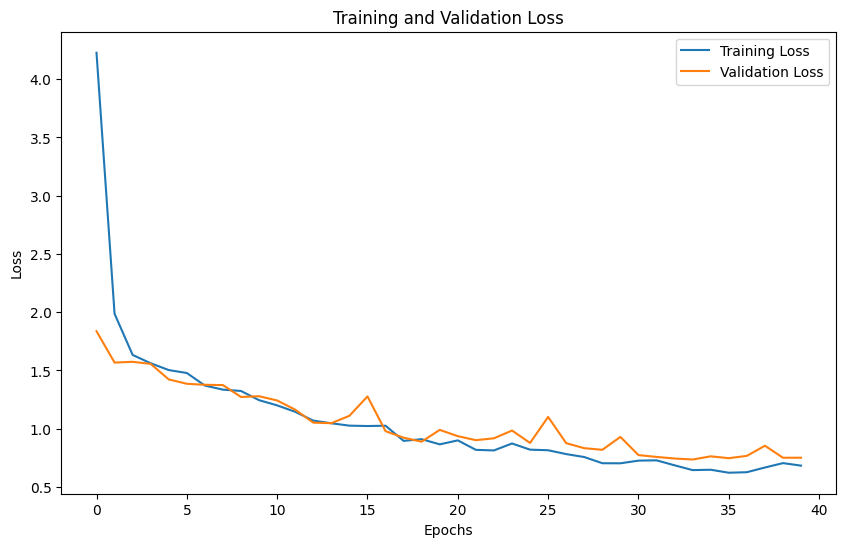


Evaluating model on test set...
Crime Level Accuracy: 0.8933
Recovery Level Accuracy: 0.8356


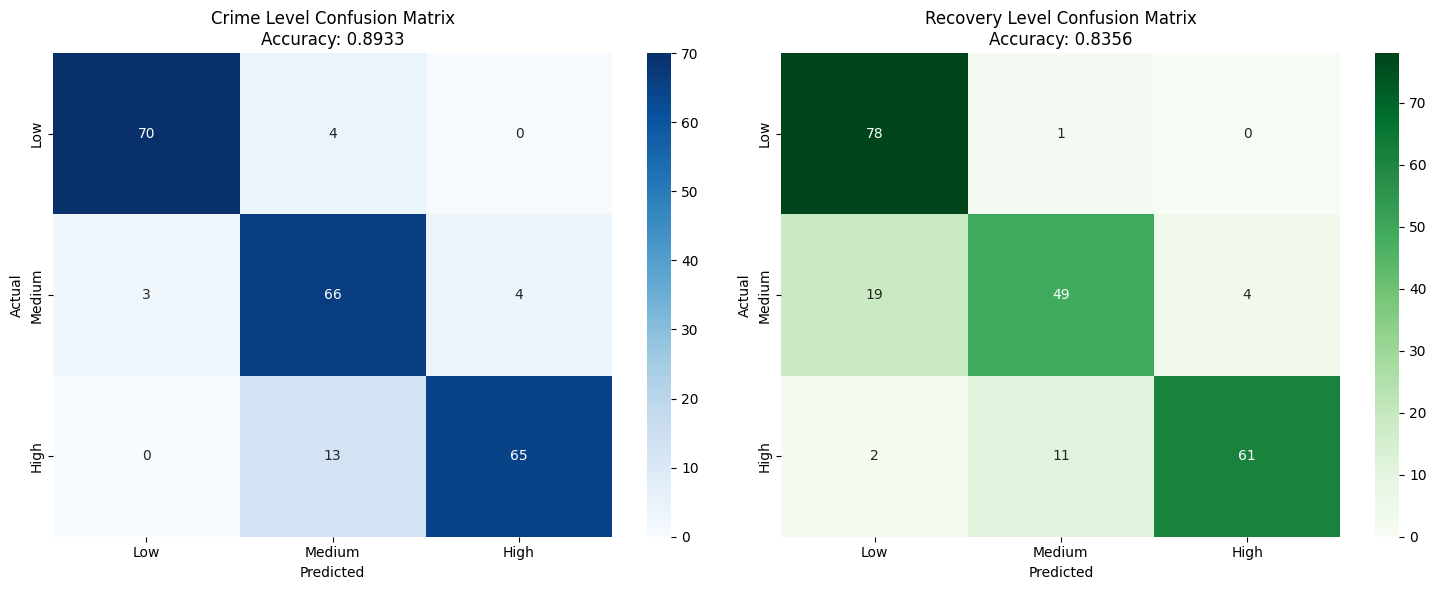


CRIME LEVEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.96      0.95      0.95        74
      Medium       0.80      0.90      0.85        73
        High       0.94      0.83      0.88        78

    accuracy                           0.89       225
   macro avg       0.90      0.89      0.89       225
weighted avg       0.90      0.89      0.89       225


RECOVERY LEVEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.79      0.99      0.88        79
      Medium       0.80      0.68      0.74        72
        High       0.94      0.82      0.88        74

    accuracy                           0.84       225
   macro avg       0.84      0.83      0.83       225
weighted avg       0.84      0.84      0.83       225


Calculating feature importance...


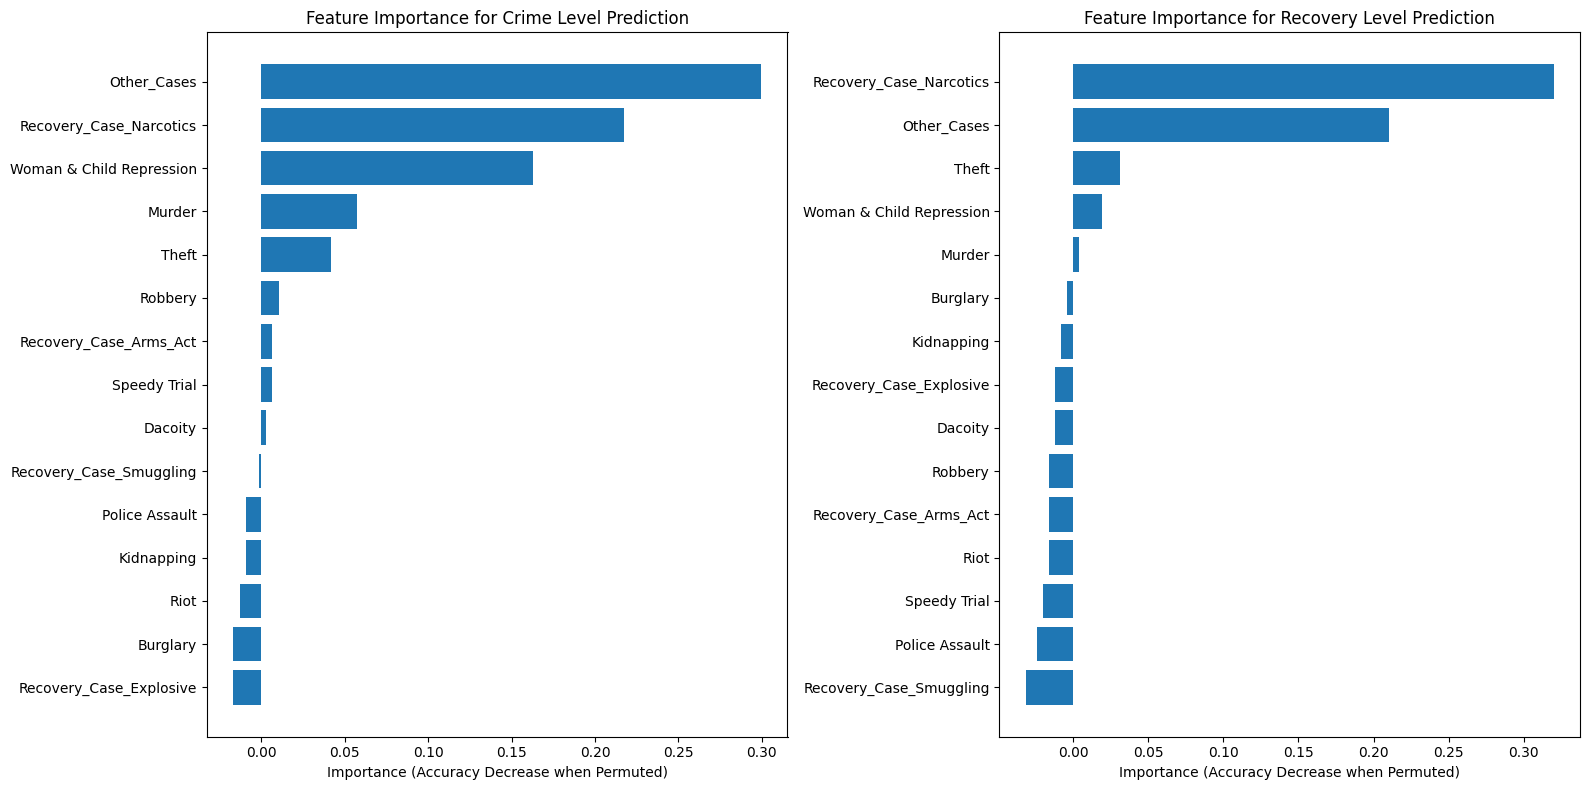


Top 5 Features for Crime Level Prediction:
  Theft: 0.0418
  Murder: 0.0574
  Woman & Child Repression: 0.1629
  Recovery_Case_Narcotics: 0.2176
  Other_Cases: 0.2996

Top 5 Features for Recovery Level Prediction:
  Murder: 0.0035
  Woman & Child Repression: 0.0191
  Theft: 0.0309
  Other_Cases: 0.2106
  Recovery_Case_Narcotics: 0.3199

Model saved as 'tcn_crime_model.pth'


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load and preprocess data
df = pd.read_csv('/content/FINAL_MONTHLY_CRIME_DATA.csv')

# Feature selection
crime_features = ['Dacoity', 'Robbery', 'Murder', 'Speedy Trial', 'Riot',
                'Woman & Child Repression', 'Kidnapping', 'Police Assault',
                'Burglary', 'Theft', 'Other_Cases', 'Recovery_Case_Arms_Act',
                'Recovery_Case_Explosive', 'Recovery_Case_Narcotics', 'Recovery_Case_Smuggling']

target_columns = ['Crime_Level', 'Recovery_Level']

# Filter relevant columns
features_df = df[['Unit Name', 'Year', 'Month'] + crime_features + target_columns].copy()

# Encode categorical targets
level_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
features_df['Crime_Level_encoded'] = features_df['Crime_Level'].map(level_mapping)
features_df['Recovery_Level_encoded'] = features_df['Recovery_Level'].map(level_mapping)

# Create sequential data with time series for each unit
def create_sequences(data, unit_name, sequence_length=6):
    unit_data = data[data['Unit Name'] == unit_name].sort_values(['Year', 'Month'])
    sequences = []
    crime_labels = []
    recovery_labels = []

    for i in range(len(unit_data) - sequence_length):
        seq = unit_data.iloc[i:i+sequence_length][crime_features].values
        crime_label = unit_data.iloc[i+sequence_length]['Crime_Level_encoded']
        recovery_label = unit_data.iloc[i+sequence_length]['Recovery_Level_encoded']

        sequences.append(seq)
        crime_labels.append(crime_label)
        recovery_labels.append(recovery_label)

    return sequences, crime_labels, recovery_labels

# Create dataset
all_sequences = []
all_crime_labels = []
all_recovery_labels = []

unique_units = features_df['Unit Name'].unique()
sequence_length = 6

for unit in unique_units:
    unit_sequences, crime_labs, recovery_labs = create_sequences(features_df, unit, sequence_length)
    all_sequences.extend(unit_sequences)
    all_crime_labels.extend(crime_labs)
    all_recovery_labels.extend(recovery_labs)

# Convert to numpy arrays
X = np.array(all_sequences)
y_crime = np.array(all_crime_labels)
y_recovery = np.array(all_recovery_labels)

print(f"Dataset shape: {X.shape}")
print(f"Crime labels distribution: {np.bincount(y_crime)}")
print(f"Recovery labels distribution: {np.bincount(y_recovery)}")

# TCN Model
class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = nn.ConstantPad1d((0, -padding), 0)  # Causal padding
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = nn.ConstantPad1d((0, -padding), 0)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TCN(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=2, dropout=0.2):
        super(TCN, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size, dropout=dropout)]

        self.network = nn.Sequential(*layers)
        self.crime_classifier = nn.Linear(num_channels[-1], 3)  # 3 classes for crime level
        self.recovery_classifier = nn.Linear(num_channels[-1], 3)  # 3 classes for recovery level

    def forward(self, x):
        # x shape: (batch, sequence_length, num_features)
        x = x.transpose(1, 2)  # Convert to (batch, num_features, sequence_length)
        out = self.network(x)
        out = out[:, :, -1]  # Take the last output for classification

        crime_out = self.crime_classifier(out)
        recovery_out = self.recovery_classifier(out)

        return crime_out, recovery_out

# Custom Dataset
class CrimeDataset(Dataset):
    def __init__(self, sequences, crime_labels, recovery_labels):
        self.sequences = torch.FloatTensor(sequences)
        self.crime_labels = torch.LongTensor(crime_labels)
        self.recovery_labels = torch.LongTensor(recovery_labels)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.crime_labels[idx], self.recovery_labels[idx]

# Split data
X_train, X_test, y_crime_train, y_crime_test, y_recovery_train, y_recovery_test = train_test_split(
    X, y_crime, y_recovery, test_size=0.2, random_state=42, stratify=y_crime
)

X_train, X_val, y_crime_train, y_crime_val, y_recovery_train, y_recovery_val = train_test_split(
    X_train, y_crime_train, y_recovery_train, test_size=0.2, random_state=42, stratify=y_crime_train
)

# Create datasets and dataloaders
train_dataset = CrimeDataset(X_train, y_crime_train, y_recovery_train)
val_dataset = CrimeDataset(X_val, y_crime_val, y_recovery_val)
test_dataset = CrimeDataset(X_test, y_crime_test, y_recovery_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model parameters
num_features = len(crime_features)
num_channels = [64, 32, 16]  # TCN channels
model = TCN(num_features, num_channels, kernel_size=3, dropout=0.3)

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# Training function
def train_model(model, train_loader, val_loader, epochs=50):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_idx, (data, crime_target, recovery_target) in enumerate(train_loader):
            optimizer.zero_grad()
            crime_pred, recovery_pred = model(data)

            crime_loss = criterion(crime_pred, crime_target)
            recovery_loss = criterion(recovery_pred, recovery_target)
            loss = crime_loss + recovery_loss

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, crime_target, recovery_target in val_loader:
                crime_pred, recovery_pred = model(data)

                crime_loss = criterion(crime_pred, crime_target)
                recovery_loss = criterion(recovery_pred, recovery_target)
                loss = crime_loss + recovery_loss

                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        scheduler.step(avg_val_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

    return train_losses, val_losses

# Train the model
print("Training TCN model...")
train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=40)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    crime_preds = []
    crime_targets = []
    recovery_preds = []
    recovery_targets = []

    crime_probs = []
    recovery_probs = []

    with torch.no_grad():
        for data, crime_target, recovery_target in test_loader:
            crime_pred, recovery_pred = model(data)

            crime_preds.extend(torch.argmax(crime_pred, dim=1).cpu().numpy())
            crime_targets.extend(crime_target.cpu().numpy())
            recovery_preds.extend(torch.argmax(recovery_pred, dim=1).cpu().numpy())
            recovery_targets.extend(recovery_target.cpu().numpy())

            crime_probs.extend(torch.softmax(crime_pred, dim=1).cpu().numpy())
            recovery_probs.extend(torch.softmax(recovery_pred, dim=1).cpu().numpy())

    return (crime_preds, crime_targets, recovery_preds, recovery_targets,
            crime_probs, recovery_probs)

# Evaluate the model
print("\nEvaluating model on test set...")
crime_preds, crime_targets, recovery_preds, recovery_targets, crime_probs, recovery_probs = evaluate_model(model, test_loader)

# Calculate accuracies
crime_accuracy = accuracy_score(crime_targets, crime_preds)
recovery_accuracy = accuracy_score(recovery_targets, recovery_preds)

print(f"Crime Level Accuracy: {crime_accuracy:.4f}")
print(f"Recovery Level Accuracy: {recovery_accuracy:.4f}")

# Confusion matrices
crime_cm = confusion_matrix(crime_targets, crime_preds)
recovery_cm = confusion_matrix(recovery_targets, recovery_preds)

# Plot confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Crime Level Confusion Matrix
sns.heatmap(crime_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'], ax=ax1)
ax1.set_title(f'Crime Level Confusion Matrix\nAccuracy: {crime_accuracy:.4f}')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Recovery Level Confusion Matrix
sns.heatmap(recovery_cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'], ax=ax2)
ax2.set_title(f'Recovery Level Confusion Matrix\nAccuracy: {recovery_accuracy:.4f}')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Detailed classification reports
print("\n" + "="*50)
print("CRIME LEVEL CLASSIFICATION REPORT")
print("="*50)
print(classification_report(crime_targets, crime_preds, target_names=['Low', 'Medium', 'High']))

print("\n" + "="*50)
print("RECOVERY LEVEL CLASSIFICATION REPORT")
print("="*50)
print(classification_report(recovery_targets, recovery_preds, target_names=['Low', 'Medium', 'High']))

# Feature importance analysis (using permutation importance)
def permutation_importance(model, test_loader, feature_names):
    model.eval()
    baseline_crime_preds = []
    baseline_recovery_preds = []
    crime_targets = []
    recovery_targets = []

    with torch.no_grad():
        for data, crime_target, recovery_target in test_loader:
            crime_pred, recovery_pred = model(data)
            baseline_crime_preds.extend(torch.argmax(crime_pred, dim=1).cpu().numpy())
            baseline_recovery_preds.extend(torch.argmax(recovery_pred, dim=1).cpu().numpy())
            crime_targets.extend(crime_target.cpu().numpy())
            recovery_targets.extend(recovery_target.cpu().numpy())

    baseline_crime_acc = accuracy_score(crime_targets, baseline_crime_preds)
    baseline_recovery_acc = accuracy_score(recovery_targets, baseline_recovery_preds)

    crime_importance = []
    recovery_importance = []

    for feature_idx in range(len(feature_names)):
        # Permute feature
        permuted_crime_acc = 0
        permuted_recovery_acc = 0
        num_batches = 0

        with torch.no_grad():
            for data, crime_target, recovery_target in test_loader:
                # Permute the specific feature across the sequence
                permuted_data = data.clone()
                permuted_data[:, :, feature_idx] = permuted_data[torch.randperm(permuted_data.size(0)), :, feature_idx]

                crime_pred, recovery_pred = model(permuted_data)
                crime_preds = torch.argmax(crime_pred, dim=1).cpu().numpy()
                recovery_preds = torch.argmax(recovery_pred, dim=1).cpu().numpy()

                permuted_crime_acc += accuracy_score(crime_target.cpu().numpy(), crime_preds)
                permuted_recovery_acc += accuracy_score(recovery_target.cpu().numpy(), recovery_preds)
                num_batches += 1

        avg_permuted_crime_acc = permuted_crime_acc / num_batches
        avg_permuted_recovery_acc = permuted_recovery_acc / num_batches

        crime_importance.append(baseline_crime_acc - avg_permuted_crime_acc)
        recovery_importance.append(baseline_recovery_acc - avg_permuted_recovery_acc)

    return crime_importance, recovery_importance

print("\nCalculating feature importance...")
crime_importance, recovery_importance = permutation_importance(model, test_loader, crime_features)

# Plot feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Crime Level Feature Importance
crime_imp_df = pd.DataFrame({
    'Feature': crime_features,
    'Importance': crime_importance
}).sort_values('Importance', ascending=True)

ax1.barh(crime_imp_df['Feature'], crime_imp_df['Importance'])
ax1.set_title('Feature Importance for Crime Level Prediction')
ax1.set_xlabel('Importance (Accuracy Decrease when Permuted)')

# Recovery Level Feature Importance
recovery_imp_df = pd.DataFrame({
    'Feature': crime_features,
    'Importance': recovery_importance
}).sort_values('Importance', ascending=True)

ax2.barh(recovery_imp_df['Feature'], recovery_imp_df['Importance'])
ax2.set_title('Feature Importance for Recovery Level Prediction')
ax2.set_xlabel('Importance (Accuracy Decrease when Permuted)')

plt.tight_layout()
plt.show()

# Print top features
print("\nTop 5 Features for Crime Level Prediction:")
for i, row in crime_imp_df.tail(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

print("\nTop 5 Features for Recovery Level Prediction:")
for i, row in recovery_imp_df.tail(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

# Save model
torch.save(model.state_dict(), 'tcn_crime_model.pth')
print("\nModel saved as 'tcn_crime_model.pth'")